In [1]:
import pandas as pd
import numpy as np

## Loading the Data

In [2]:
DATA_URL = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"

raw = pd.read_csv(DATA_URL, parse_dates=["date"])
print("Rows:", len(raw))
print("Date Range:", raw["date"].min().date(), "to", raw["date"].max().date())
print("Columns:", raw.columns.tolist())

raw

Rows: 49472
Date Range: 1872-11-30 to 2026-06-27
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49467,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49468,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49469,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49470,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


In [ ]:
df = raw.dropna(subset=["home_score", "away_score"]).copy()
df["home_score"] = df["home_score"].astype(int)
df["away_score"] = df["away_score"].astype(int)

#Sorting the data in chronological order
df = df.sort_values("date", kind="mergesort").reset_index(drop=True)

print(f"{len(df):,} played matches, up to {df['date'].max().date()}")

49,400 played matches, up to 2026-06-09


## CONSTANTS

In [4]:
START_RATING = 1500
SCALE = 400
HOME_ADVANTAGE = 100

## Expected Score

In [5]:
def expected_score(rating_a, rating_b):
    """Calculate the expected score for team A against team B."""
    return 1.0 / (1.0 + 10 ** ((rating_b - rating_a) / SCALE))

print(expected_score(1500, 1500))  
print(expected_score(1900, 1500))


0.5
0.9090909090909091


## Actual Score

In [12]:
def actual_score(home_score, away_score):
    """Calculate the actual score for the home team."""
    if home_score > away_score:
        return 1.0
    elif home_score == away_score:
        return 0.5
    else:
        return 0.0

## K-FACTOR

In [6]:
def k_factor(tournament):
    t = tournament.lower()
    if "friendly" in t:
        return 20.0
    if "qualification" in t or "qualifier"in t or "nations league" in t:
        return 40.0
    if "world cup" in t:
        return 60.0
    if any(c in t for c in ["euro", "copa","african cup", "asian cup", "gold cup", "confederations"]):
        return 50.0
    return 30.0

for t in ["Friendly", "FIFA World Cup qualification", "FIFA World Cup", "UEFA Euro"]:
    print(f"{t:<32}: K={k_factor(t)}")

Friendly                        : K=20.0
FIFA World Cup qualification    : K=40.0
FIFA World Cup                  : K=60.0
UEFA Euro                       : K=50.0


In [9]:
def margin_multiplier(goal_diff):
    """Calculate the margin of victory multiplier."""
    gd = abs(goal_diff)
    if gd <= 1:
        return 1.0
    elif gd == 2:
        return 1.5
    elif gd == 3:
        return 1.75
    else:
        return 1.75 + (gd - 3) / 8.0
    
for gd in range(0, 6):
    print(f"GD={gd}: Multiplier={margin_multiplier(gd):.2f}")

GD=0: Multiplier=1.00
GD=1: Multiplier=1.00
GD=2: Multiplier=1.50
GD=3: Multiplier=1.75
GD=4: Multiplier=1.88
GD=5: Multiplier=2.00


In [10]:
def run_elo(df):
    ratings={}
    feature_rows = []

    for m in df.itertuples(index=False):
        r_home = ratings.get(m.home_team, START_RATING)
        r_away = ratings.get(m.away_team, START_RATING)

        feature_rows.append({
            "date":m.date,
            "home_team": m.home_team,
            "away_team": m.away_team,
            "elo_home_pre": r_home,
            "elo_away_pre": r_away,
            "neutral": bool(m.neutral),
            "home_score": m.home_score,
            "away_score": m.away_score,
            "tournament": m.tournament
        })

        ha = 0.0 if m.neutral else HOME_ADVANTAGE
        exp_home = expected_score(r_home + ha, r_away)

        k = k_factor(m.tournament) * margin_multiplier(m.home_score - m.away_score)
        delta = k * (actual_score(m.home_score, m.away_score) - exp_home)

        ratings[m.home_team] = r_home + delta
        ratings[m.away_team] = r_away - delta

    return ratings, pd.DataFrame(feature_rows)

In [15]:
ratings, features = run_elo(df)

current = (pd.Series(ratings, name="elo")
              .sort_values(ascending=False)
              .rename_axis("team")
              .reset_index()   
           )

current["rank"] = range(1, len(current) + 1)
current.head(15)

,team,elo,rank
0,Spain,2217.553555,1
1,Argentina,2188.794559,2
2,France,2123.547319,3
3,England,2084.775726,4
4,Brazil,2067.768667,5
5,Colombia,2062.662941,6
6,Portugal,2041.206462,7
7,Ecuador,2026.573890,8
8,Netherlands,2009.352609,9
9,Germany,2003.252299,10


In [16]:
print(current.head(20)[["rank", "team", "elo"]].to_string(index=False))

print("\nSelected teams:")
for t in ["Argentina","France","Spain","Brazil","England","Germany","USA","Mexico","Canada"]:
    row = current[current["team"] == t]
    if not row.empty:
        print(f"  {t:<10} #{int(row['rank'].iloc[0]):<3} {row['elo'].iloc[0]:,.0f}")

 rank        team         elo
    1       Spain 2217.553555
    2   Argentina 2188.794559
    3      France 2123.547319
    4     England 2084.775726
    5      Brazil 2067.768667
    6    Colombia 2062.662941
    7    Portugal 2041.206462
    8     Ecuador 2026.573890
    9 Netherlands 2009.352609
   10     Germany 2003.252299
   11       Japan 1992.394862
   12     Morocco 1984.270110
   13      Mexico 1979.100742
   14     Uruguay 1974.347362
   15      Norway 1969.978626
   16     Croatia 1968.028464
   17      Turkey 1967.998803
   18     Belgium 1955.423004
   19 Switzerland 1954.638567
   20       Italy 1927.182864

Selected teams:
  Argentina  #2   2,189
  France     #3   2,124
  Spain      #1   2,218
  Brazil     #5   2,068
  England    #4   2,085
  Germany    #10  2,003
  Mexico     #13  1,979
  Canada     #25  1,898


In [17]:
import os
os.makedirs("outputs", exist_ok=True)
current.to_csv("outputs/current_ratings.csv", index=False)
features.to_csv("outputs/match_features.csv", index=False)
print("saved.")

saved.


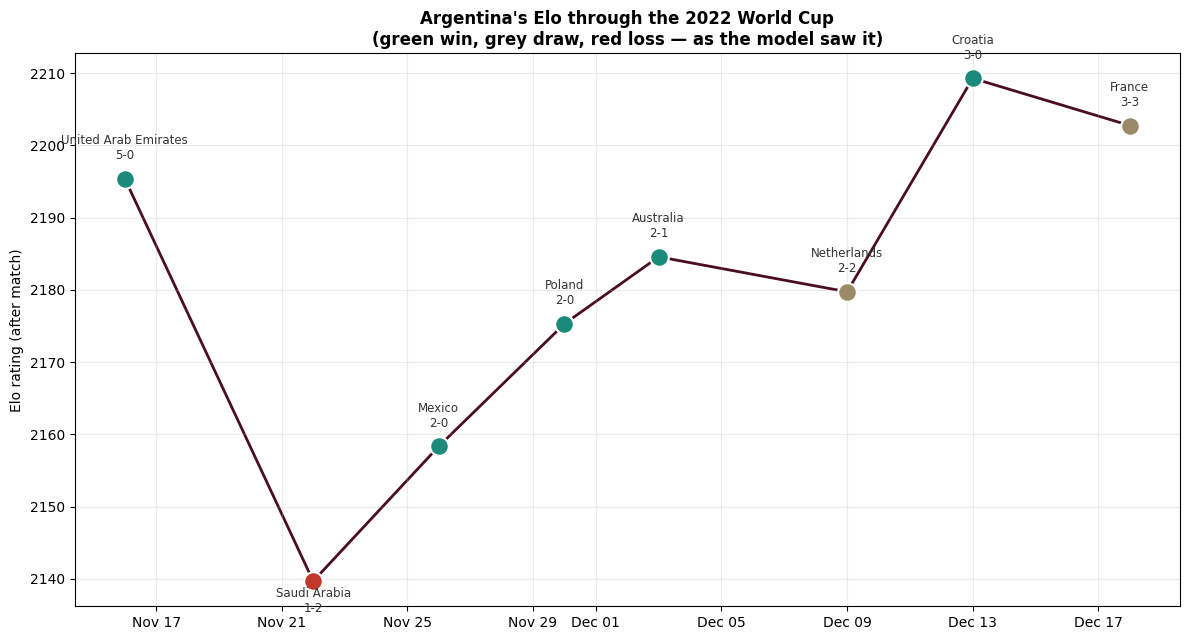

In [18]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Argentina's matches across the 2022 World Cup window
mask = (((features.home_team == "Argentina") | (features.away_team == "Argentina"))
        & (features.date >= "2022-11-10") & (features.date <= "2022-12-20"))
arg = features[mask].sort_values("date")

dates, posts, labels, results = [], [], [], []
for r in arg.itertuples():
    home    = r.home_team == "Argentina"
    pre     = r.elo_home_pre if home else r.elo_away_pre        # Argentina going in
    opp_pre = r.elo_away_pre if home else r.elo_home_pre
    gf      = r.home_score if home else r.away_score
    ga      = r.away_score if home else r.home_score
    ha      = 0.0 if r.neutral else HOME_ADVANTAGE              # neutral at a WC
    exp     = expected_score(pre + (ha if home else 0), opp_pre + (0 if home else ha))
    k       = k_factor(r.tournament) * margin_multiplier(gf - ga)
    post    = pre + k * (actual_score(gf, ga) - exp)            # rating AFTER the match
    opp     = r.away_team if home else r.home_team
    dates.append(r.date); posts.append(post)
    labels.append(f"{opp}\n{gf}-{ga}")
    results.append("W" if gf > ga else ("L" if gf < ga else "D"))

colour = {"W": "#1c8a7a", "D": "#9a8a6a", "L": "#c0392b"}
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.plot(dates, posts, "-", color="#4a0e1e", lw=2, zorder=1)
for d, p, l, res in zip(dates, posts, labels, results):
    ax.scatter([d], [p], s=180, color=colour[res], edgecolor="white", lw=1.5, zorder=3)
    ax.annotate(l, (d, p), textcoords="offset points", xytext=(0, 14 if res != "L" else -22),
                ha="center", fontsize=8.5, color="#333")
ax.set_title("Argentina's Elo through the 2022 World Cup\n"
             "(green win, grey draw, red loss — as the model saw it)", weight="bold")
ax.set_ylabel("Elo rating (after match)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()